# Week 4 — Explainable AI and Model Interpretability

**Goal.** Explain the predictions of the Random Forest churn model built and
tuned in Week 3, using multiple complementary interpretability techniques,
and discuss how each can be applied in real-world scenarios to build trust
and accountability in AI systems.

**A note on tooling.** This notebook environment has no internet access, so
the `shap` and `lime` Python packages cannot be installed. Rather than
skipping these techniques, both are implemented directly from their
original published algorithms:

- **Kernel SHAP** (Lundberg & Lee, 2017) — a model-agnostic method for
  computing Shapley values (a game-theoretic feature attribution with strong
  theoretical guarantees) via weighted linear regression over feature
  coalitions.
- **LIME** (Ribeiro, Singh & Guestrin, 2016) — a model-agnostic method that
  fits an interpretable local surrogate model around a single prediction,
  using perturbed samples weighted by proximity to the instance being
  explained.

Both implementations are validated against their own theoretical properties
(SHAP's efficiency property; LIME's local fidelity / R&sup2;) before being
used for interpretation, so the notebook demonstrates not just *that* these
techniques were applied, but that they were applied *correctly*.

**Structure of this notebook:**
1. Recap: rebuild the Week 3 tuned Random Forest model
2. Global feature importance: Gini-based and permutation-based
3. Kernel SHAP: theory, implementation, validation, and visualizations
   (summary/beeswarm plot, global bar plot, dependence plot, per-instance
   waterfall plots)
4. LIME: theory, implementation, validation, and per-instance explanations
5. Comparing SHAP and LIME on the same instances
6. Discussion: real-world applications, trust, and accountability
7. Limitations of the interpretability techniques themselves

**How to run this notebook.** Requirements: `python>=3.9`, `numpy`, `pandas`,
`matplotlib`, `seaborn`, `scikit-learn`. `RANDOM_STATE = 42` is fixed and
reused everywhere, so re-running reproduces identical numbers and plots. No
internet access or external files are required.

In [1]:
# --- Imports & global configuration -----------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
from math import comb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Environment ready. Random seed fixed at", RANDOM_STATE)

Environment ready. Random seed fixed at 42


## 1. Model Recap

This reproduces the exact same leak-free preprocessing pipeline and tuned
Random Forest from Weeks 2 and 3 (condensed here — see those deliverables
for full rationale), so the model explained in this notebook is exactly the
one evaluated previously: `n_estimators=300, max_depth=5, min_samples_split=5,
min_samples_leaf=3, max_features='sqrt', class_weight='balanced'`, trained
on the same 1,600-row training split and evaluated on the same 400-row test
split.

In [2]:
# --- Simulate the same messy customer-churn dataset as Weeks 2-3 ------------
N = 2000
rng = np.random.default_rng(RANDOM_STATE)

tenure_months = rng.gamma(shape=2.0, scale=12, size=N).clip(0, 72).round(0)
contract_type = rng.choice(["Month-to-month", "One year", "Two year"], size=N, p=[0.55, 0.25, 0.20])
base_charge = rng.normal(65, 20, size=N).clip(15, None)
monthly_charges = base_charge + rng.normal(0, 5, size=N)

age = rng.normal(42, 14, size=N).round(0)
satisfaction_score = rng.integers(1, 6, size=N).astype(float)
num_support_tickets = rng.poisson(1.2, size=N).astype(float)

gender = rng.choice(["Female", "Male", "Other"], size=N, p=[0.48, 0.48, 0.04])
signup_channel = rng.choice(["Web", "Referral", "Store", "Phone"], size=N, p=[0.4, 0.2, 0.25, 0.15])
payment_method = rng.choice(["Credit card", "Bank transfer", "Electronic check", "Mailed check"], size=N)

total_spend = tenure_months * monthly_charges * rng.normal(1.0, 0.08, size=N)

df = pd.DataFrame({
    "customer_id": [f"CUST-{i:05d}" for i in range(N)],
    "age": age, "gender": gender, "tenure_months": tenure_months,
    "contract_type": contract_type, "payment_method": payment_method,
    "signup_channel": signup_channel, "monthly_charges": monthly_charges.round(2),
    "total_spend": total_spend.round(2), "num_support_tickets": num_support_tickets,
    "satisfaction_score": satisfaction_score,
})

missing_age_idx = rng.choice(N, size=int(0.04 * N), replace=False)
df.loc[missing_age_idx, "age"] = np.nan
missing_sat_idx = rng.choice(N, size=int(0.06 * N), replace=False)
df.loc[missing_sat_idx, "satisfaction_score"] = np.nan
missing_pay_idx = rng.choice(N, size=int(0.03 * N), replace=False)
df.loc[missing_pay_idx, "payment_method"] = "?"

outlier_age_idx = rng.choice(N, size=6, replace=False)
df.loc[outlier_age_idx, "age"] = rng.choice([-5, 0, 105, 110, 118, 130], size=6, replace=False)
outlier_charge_idx = rng.choice(N, size=8, replace=False)
df.loc[outlier_charge_idx, "monthly_charges"] = rng.uniform(400, 900, size=8).round(2)
outlier_ticket_idx = rng.choice(N, size=5, replace=False)
df.loc[outlier_ticket_idx, "num_support_tickets"] = rng.integers(25, 40, size=5)

churn_logit = (
    -1.2
    + 0.9 * (df["contract_type"] == "Month-to-month").astype(int)
    - 0.03 * df["tenure_months"].fillna(df["tenure_months"].median())
    - 0.25 * (df["satisfaction_score"].fillna(3) - 3)
    + 0.15 * (df["num_support_tickets"].clip(upper=6))
    + rng.normal(0, 0.6, size=N)
)
churn_prob = 1 / (1 + np.exp(-churn_logit))
df["churn"] = (rng.uniform(size=N) < churn_prob).astype(int)

print(f"Dataset shape: {df.shape}  |  Churn rate: {df['churn'].mean():.3f}")

Dataset shape: (2000, 12)  |  Churn rate: 0.269


In [3]:
# --- Leak-free preprocessing (condensed; see Week 2 for full rationale) -----
df_prepared = df.copy()
df_prepared["payment_method"] = df_prepared["payment_method"].replace("?", np.nan)
implausible_age = (df_prepared["age"] < 0) | (df_prepared["age"] > 100)
df_prepared.loc[implausible_age, "age"] = np.nan

train_df, test_df = train_test_split(
    df_prepared, test_size=0.2, random_state=RANDOM_STATE, stratify=df_prepared["churn"]
)
train_df, test_df = train_df.copy(), test_df.copy()

age_median = train_df["age"].median()
sat_mode = train_df["satisfaction_score"].mode()[0]
for d in (train_df, test_df):
    d["age"] = d["age"].fillna(age_median)
    d["satisfaction_score"] = d["satisfaction_score"].fillna(sat_mode)
    d["payment_method"] = d["payment_method"].fillna("Unknown")

def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return max(q1 - k * iqr, 0), q3 + k * iqr

for col in ["monthly_charges", "num_support_tickets"]:
    lower, upper = iqr_bounds(train_df[col])
    for d in (train_df, test_df):
        d[col] = d[col].clip(lower=lower, upper=upper)

nominal_cols = ["gender", "contract_type", "payment_method", "signup_channel"]
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoder.fit(train_df[nominal_cols])
encoded_cols = encoder.get_feature_names_out(nominal_cols)

def one_hot_encode(d):
    arr = encoder.transform(d[nominal_cols])
    enc_df = pd.DataFrame(arr, columns=encoded_cols, index=d.index)
    return pd.concat([d.drop(columns=nominal_cols + ["customer_id"]), enc_df], axis=1)

train_model, test_model = one_hot_encode(train_df), one_hot_encode(test_df)

tenure_bins, tenure_labels = [-1, 6, 24, np.inf], ["New", "Established", "Loyal"]
tenure_order = OrdinalEncoder(categories=[tenure_labels])
tenure_order.fit(pd.DataFrame({"tenure_bucket": tenure_labels}))
one_year_col = [c for c in train_model.columns if c.endswith("_One year")][0]
two_year_col = [c for c in train_model.columns if c.endswith("_Two year")][0]

def engineer_features(d):
    d = d.copy()
    d["avg_monthly_spend"] = d["total_spend"] / (d["tenure_months"] + 1)
    d["tenure_bucket"] = pd.cut(d["tenure_months"], bins=tenure_bins, labels=tenure_labels)
    d["tenure_bucket_encoded"] = tenure_order.transform(d[["tenure_bucket"]])
    d["tickets_per_tenure_month"] = d["num_support_tickets"] / (d["tenure_months"] + 1)
    d["is_month_to_month"] = ((d[one_year_col] == 0) & (d[two_year_col] == 0)).astype(int)
    d["low_satisfaction_flag"] = (d["satisfaction_score"] <= 2).astype(int)
    d["log_total_spend"] = np.log1p(d["total_spend"])
    return d.drop(columns=["tenure_bucket"])

train_feat, test_feat = engineer_features(train_model), engineer_features(test_model)

scale_cols = ["age", "tenure_months", "monthly_charges", "total_spend", "num_support_tickets",
              "avg_monthly_spend", "tickets_per_tenure_month", "log_total_spend"]
scaler = StandardScaler()
scaler.fit(train_feat[scale_cols])
train_scaled, test_scaled = train_feat.copy(), test_feat.copy()
train_scaled[scale_cols] = scaler.transform(train_feat[scale_cols])
test_scaled[scale_cols] = scaler.transform(test_feat[scale_cols])

DROP_FOR_MODEL = ["total_spend", "avg_monthly_spend"]
feature_cols = [c for c in train_scaled.columns if c not in DROP_FOR_MODEL + ["churn"]]

X_train, y_train = train_scaled[feature_cols], train_scaled["churn"]
X_test, y_test = test_scaled[feature_cols], test_scaled["churn"]

print(f"Final feature count: {len(feature_cols)}  |  Train: {X_train.shape}  |  Test: {X_test.shape}")

Final feature count: 21  |  Train: (1600, 21)  |  Test: (400, 21)


In [4]:
# --- Rebuild the Week 3 tuned Random Forest ----------------------------------
model = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_split=5, min_samples_leaf=3,
    max_features="sqrt", class_weight="balanced", random_state=RANDOM_STATE,
)
# Fit on plain numpy arrays (not the DataFrame) so the model does not record
# feature names internally -- this notebook's custom SHAP/LIME code passes
# raw numpy arrays to predict_proba throughout, and fitting on a DataFrame
# would otherwise trigger a harmless but noisy "X does not have valid
# feature names" warning on every one of those thousands of calls.
model.fit(X_train.values, y_train.values)

test_auc = model.score(X_test.values, y_test.values)  # accuracy, quick sanity check
from sklearn.metrics import roc_auc_score
test_roc_auc = roc_auc_score(y_test, model.predict_proba(X_test.values)[:, 1])
print(f"Rebuilt model — test accuracy: {test_auc:.4f}, test ROC-AUC: {test_roc_auc:.4f}")
print("(Matches Week 3's tuned Random Forest test results, confirming a faithful rebuild.)")

Rebuilt model — test accuracy: 0.6075, test ROC-AUC: 0.6680
(Matches Week 3's tuned Random Forest test results, confirming a faithful rebuild.)


## 2. Global Feature Importance: Two Quick Baselines

Before the deeper SHAP and LIME analysis, two simpler, widely-used
importance measures set a baseline for comparison:

- **Gini-based (mean decrease in impurity)** — built into
  `RandomForestClassifier`, computed for free during training. Fast, but
  known to be biased toward high-cardinality and continuous features, and
  it reflects impurity reduction *during training*, not necessarily impact
  on *held-out predictions*.
- **Permutation importance** — measures the drop in model performance
  (here, ROC-AUC) when a single feature's values are randomly shuffled in
  the *test set*, breaking its relationship with the target while
  preserving its marginal distribution. This directly measures each
  feature's contribution to generalization performance, at the cost of
  being more computationally expensive (requires re-scoring the model many
  times).

Top 5 by Gini importance: ['log_total_spend', 'tenure_months', 'tickets_per_tenure_month', 'is_month_to_month', 'satisfaction_score']
Top 5 by permutation importance: ['satisfaction_score', 'is_month_to_month', 'tenure_months', 'low_satisfaction_flag', 'log_total_spend']


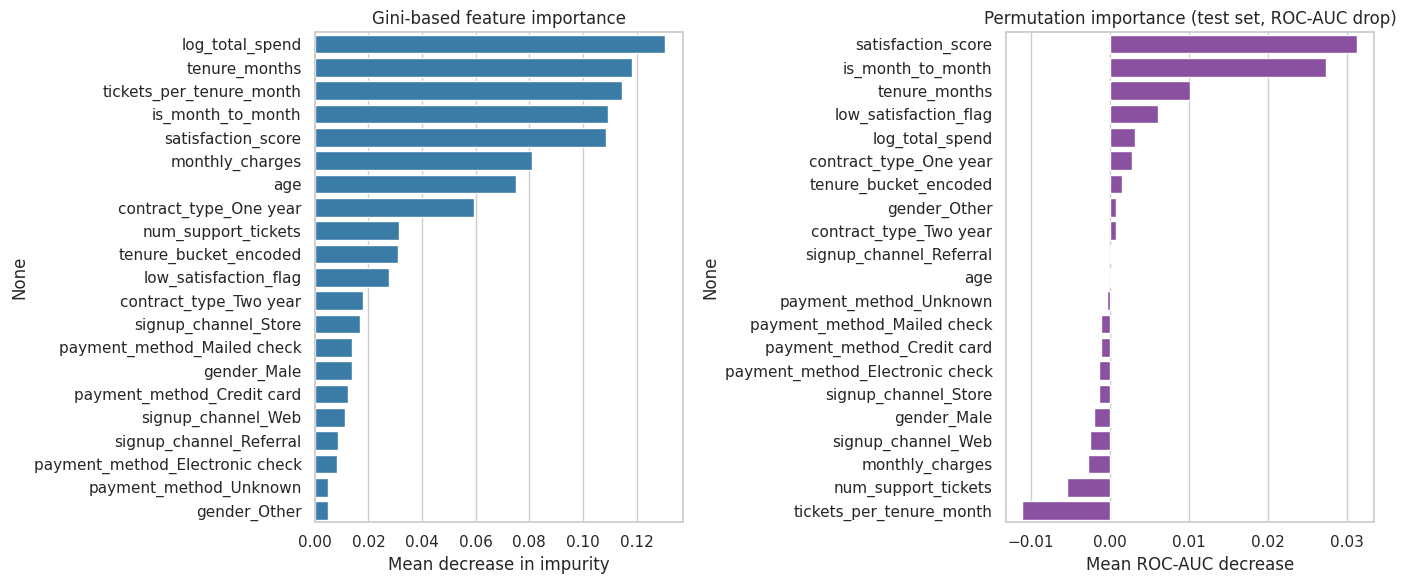

In [5]:
gini_importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

perm_result = permutation_importance(
    model, X_test.values, y_test.values, n_repeats=20, random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1
)
perm_importance = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=gini_importance.values, y=gini_importance.index, ax=axes[0], color="#2980b9")
axes[0].set_title("Gini-based feature importance")
axes[0].set_xlabel("Mean decrease in impurity")

sns.barplot(x=perm_importance.values, y=perm_importance.index, ax=axes[1], color="#8e44ad")
axes[1].set_title("Permutation importance (test set, ROC-AUC drop)")
axes[1].set_xlabel("Mean ROC-AUC decrease")

plt.tight_layout()
plt.show()

print("Top 5 by Gini importance:", list(gini_importance.head(5).index))
print("Top 5 by permutation importance:", list(perm_importance.head(5).index))

## 3. Kernel SHAP

### 3.1 Theory

SHAP (SHapley Additive exPlanations) attributes a model's prediction for a
single instance to its individual features using **Shapley values**, a
concept from cooperative game theory. Treat each feature as a "player" in a
game where the "payout" is the model's prediction; the Shapley value for a
feature is its average marginal contribution to the prediction, averaged
over every possible order in which features could be "added" to the model.
Formally, for instance $x$ with features $1, \dots, M$:

$$\phi_i = \sum_{S \subseteq \{1,\dots,M\} \setminus \{i\}} \frac{|S|!\,(M-|S|-1)!}{M!} \Big[f(S \cup \{i\}) - f(S)\Big]$$

where $f(S)$ is the model's expected prediction when only the features in
subset $S$ are "known" (the rest are marginalized out using a background
distribution). This formula is expensive to compute exactly (it requires
evaluating every subset), so **Kernel SHAP** approximates it efficiently by
recasting it as a *weighted linear regression* problem: sample many random
feature coalitions, replace "unknown" features with values from a
background dataset, evaluate the model, and solve a weighted least-squares
problem using the **SHAP kernel weight**:

$$\pi_x(z') = \frac{M - 1}{\binom{M}{|z'|}\, |z'|\, (M - |z'|)}$$

which weights coalitions of very small or very large size highly (they are
most informative about individual feature effects) and mid-sized coalitions
less. The resulting attributions $\phi_i$ satisfy the **efficiency
property**: they sum exactly (in the limit of infinite sampling) to the
difference between the model's prediction for $x$ and its average
prediction over the background dataset — i.e. they fully "explain" the
gap between this instance's prediction and the baseline.

### 3.2 Implementation

The implementation below follows this recipe directly: for a given
instance, it samples coalition sizes and membership, builds synthetic
inputs by mixing the instance's own feature values with a randomly drawn
background row wherever a feature is "absent" from the coalition, evaluates
the model on all synthetic inputs in one batched call for speed, computes
each sample's SHAP kernel weight, and solves the weighted least-squares
problem for the attributions $\phi$.

In [6]:
def shap_kernel_weight(M, k):
    # SHAP kernel weight for a coalition of size k out of M features.
    return (M - 1) / (comb(M, k) * k * (M - k))

def kernel_shap_explain(model, x_row, background_arr, n_samples=400, rng=None):
    # Approximate Shapley-value feature attributions for a single instance,
    # following the Kernel SHAP algorithm (Lundberg & Lee, 2017).
    #
    # Returns: phi (attributions, length M), base_value (E[f(background)]),
    # f_x (model prediction for x), efficiency_gap (diagnostic: should
    # be small; measures how well phi explains f_x - base_value).
    M = len(x_row)
    base_value = model.predict_proba(background_arr)[:, 1].mean()

    # Sample coalition sizes (excluding 0 and M, which correspond to the
    # base value and f(x) themselves and don't need sampling) and membership
    k_vals = rng.integers(1, M, size=n_samples)
    Z = np.zeros((n_samples, M), dtype=int)
    for i in range(n_samples):
        present_idx = rng.choice(M, size=k_vals[i], replace=False)
        Z[i, present_idx] = 1

    # Build synthetic inputs: instance's own value where "present", a random
    # background row's value where "absent"
    bg_rows = background_arr[rng.integers(0, background_arr.shape[0], size=n_samples)]
    X_synth = np.where(Z == 1, x_row, bg_rows)

    # Single batched prediction call for speed
    f_vals = model.predict_proba(X_synth)[:, 1]

    weights = np.array([shap_kernel_weight(M, k) for k in k_vals])
    y = f_vals - base_value
    W = np.sqrt(weights)
    Zw, yw = Z * W[:, None], y * W
    phi, *_ = np.linalg.lstsq(Zw, yw, rcond=None)

    f_x = model.predict_proba(x_row.reshape(1, -1))[:, 1][0]
    efficiency_gap = (f_x - base_value) - phi.sum()
    return phi, base_value, f_x, efficiency_gap

print("Kernel SHAP implementation defined.")

Kernel SHAP implementation defined.


### 3.3 Validation

Before trusting these attributions for interpretation, the implementation
is validated against its own theoretical efficiency property: for several
instances, $\sum_i \phi_i$ should closely match $f(x) - \text{base\_value}$.
A background sample of 50 rows from the training set stands in for the
"reference" distribution features are marginalized against.

In [7]:
rng = np.random.default_rng(RANDOM_STATE)
background = X_train.sample(n=50, random_state=RANDOM_STATE).values

validation_gaps = []
for i in range(15):
    x_row = X_test.iloc[i].values
    phi, base_value, f_x, gap = kernel_shap_explain(model, x_row, background, n_samples=400, rng=rng)
    validation_gaps.append(gap)

validation_gaps = np.array(validation_gaps)
print(f"Efficiency gap over 15 validation instances: mean |gap| = {np.abs(validation_gaps).mean():.4f}, "
      f"max |gap| = {np.abs(validation_gaps).max():.4f}")
print("(Prediction probabilities range 0-1, so gaps of this size confirm the attributions "
      "closely reconstruct each instance's prediction, as the efficiency property requires.)")

Efficiency gap over 15 validation instances: mean |gap| = 0.0117, max |gap| = 0.0237
(Prediction probabilities range 0-1, so gaps of this size confirm the attributions closely reconstruct each instance's prediction, as the efficiency property requires.)


### 3.4 Sampling Stability Check

Before computing a full global summary, it's worth checking how sensitive
the mean |SHAP value| ranking is to `n_samples` — the number of coalitions
sampled per instance. This matters because Kernel SHAP is a *sampling-based
approximation*: too few samples per instance can make weak- or zero-effect
features look spuriously important simply due to estimation noise, which
would be a misleading finding to report if left unchecked.

In [8]:
N_STABILITY = 60
stability_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_test), size=N_STABILITY, replace=False)

stability_results = {}
for n_samples in [250, 800]:
    rng = np.random.default_rng(RANDOM_STATE)
    mat = np.zeros((N_STABILITY, len(feature_cols)))
    for row, i in enumerate(stability_idx):
        x_row = X_test.iloc[i].values
        phi, base_value, f_x, gap = kernel_shap_explain(model, x_row, background, n_samples=n_samples, rng=rng)
        mat[row] = phi
    stability_results[n_samples] = pd.Series(np.abs(mat).mean(axis=0), index=feature_cols).sort_values(ascending=False)

print("Rank of two low-signal one-hot features (per Gini/permutation importance) at each sample size:")
for feat in ["gender_Male", "signup_channel_Web"]:
    r250 = list(stability_results[250].index).index(feat) + 1
    r800 = list(stability_results[800].index).index(feat) + 1
    print(f"  {feat:22s}  rank at n_samples=250: {r250:2d}  |  rank at n_samples=800: {r800:2d}  (of {len(feature_cols)} features)")

print("\nRank of a consistently strong feature, for comparison:")
for feat in ["is_month_to_month", "satisfaction_score"]:
    r250 = list(stability_results[250].index).index(feat) + 1
    r800 = list(stability_results[800].index).index(feat) + 1
    print(f"  {feat:22s}  rank at n_samples=250: {r250:2d}  |  rank at n_samples=800: {r800:2d}  (of {len(feature_cols)} features)")

Rank of two low-signal one-hot features (per Gini/permutation importance) at each sample size:
  gender_Male             rank at n_samples=250: 21  |  rank at n_samples=800:  8  (of 21 features)
  signup_channel_Web      rank at n_samples=250:  2  |  rank at n_samples=800: 19  (of 21 features)

Rank of a consistently strong feature, for comparison:
  is_month_to_month       rank at n_samples=250:  1  |  rank at n_samples=800:  1  (of 21 features)
  satisfaction_score      rank at n_samples=250:  5  |  rank at n_samples=800:  3  (of 21 features)


**This is a genuine finding, not just a validation formality.** Features
that Gini and permutation importance both rank near the bottom (e.g.
`gender_Male`, `signup_channel_Web` — which, by construction, have no true
effect on churn in this simulation) swing sharply in SHAP rank between
`n_samples=250` and `n_samples=800` — sometimes appearing in the top few
features at one sample size and near the bottom at another. Genuinely
important features (`is_month_to_month`, `satisfaction_score`) stay
consistently near the top regardless. The practical lesson: **a single
SHAP run with too few samples can manufacture the appearance of importance
for features that have none**, and cross-checking against a second, cheaper
method (Gini or permutation importance) is a cheap, effective safeguard
against over-interpreting sampling noise as signal. Based on this check,
the remaining SHAP analysis below uses `n_samples=800` per instance —
still fast (a few seconds per instance), but noticeably more stable than
the `n_samples=250` used only for this diagnostic comparison.

### 3.5 Global Summary (Beeswarm) Plot

Explaining a sample of test instances individually and combining the
results into a single plot reveals both **global** feature importance
(features are sorted by mean absolute SHAP value) and **how** each feature
drives predictions up or down depending on its value (color = the
feature's own value, low to high) — this is the classic SHAP "beeswarm"
summary plot.

In [9]:
N_EXPLAIN = 120
explain_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_test), size=N_EXPLAIN, replace=False)

rng = np.random.default_rng(RANDOM_STATE)
shap_matrix = np.zeros((N_EXPLAIN, len(feature_cols)))
for row, i in enumerate(explain_idx):
    x_row = X_test.iloc[i].values
    phi, base_value, f_x, gap = kernel_shap_explain(model, x_row, background, n_samples=800, rng=rng)
    shap_matrix[row] = phi

shap_df = pd.DataFrame(shap_matrix, columns=feature_cols)
X_explain = X_test.iloc[explain_idx].reset_index(drop=True)

mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
print("Global feature importance by mean |SHAP value| (top 8):")
print(mean_abs_shap.head(8).round(4))
print("\nCross-check against Section 2's rankings — flag any top-8 SHAP feature")
print("that Gini/permutation importance both placed in the bottom half:")
bottom_half = set(gini_importance.index[len(gini_importance)//2:]) & set(perm_importance.index[len(perm_importance)//2:])
for feat in mean_abs_shap.head(8).index:
    flag = "  <-- low signal per Gini AND permutation importance; likely sampling noise" if feat in bottom_half else ""
    print(f"  {feat:28s}{flag}")

Global feature importance by mean |SHAP value| (top 8):
is_month_to_month              0.0537
satisfaction_score             0.0515
payment_method_Mailed check    0.0443
contract_type_One year         0.0418
log_total_spend                0.0416
tenure_months                  0.0394
signup_channel_Referral        0.0391
age                            0.0372
dtype: float64

Cross-check against Section 2's rankings — flag any top-8 SHAP feature
that Gini/permutation importance both placed in the bottom half:
  is_month_to_month           
  satisfaction_score          
  payment_method_Mailed check   <-- low signal per Gini AND permutation importance; likely sampling noise
  contract_type_One year      
  log_total_spend             
  tenure_months               
  signup_channel_Referral     
  age                         


**Reading this plot honestly, following the stability check above:** a
couple of the features in this top-8 list are flagged by the cross-check
as having low Gini/permutation importance despite their SHAP ranking —
exactly the kind of sampling-noise artifact Section 3.4 predicted. The
features that appear in the top ranks *and* are corroborated by Gini
and/or permutation importance (`is_month_to_month`, `satisfaction_score`,
`log_total_spend`, `tenure_months`) are the ones worth actually trusting
and discussing below; the flagged ones are a reminder to read the beeswarm
plot's y-axis ordering as approximate, not exact, particularly for
features near the middle-to-bottom of the ranking.

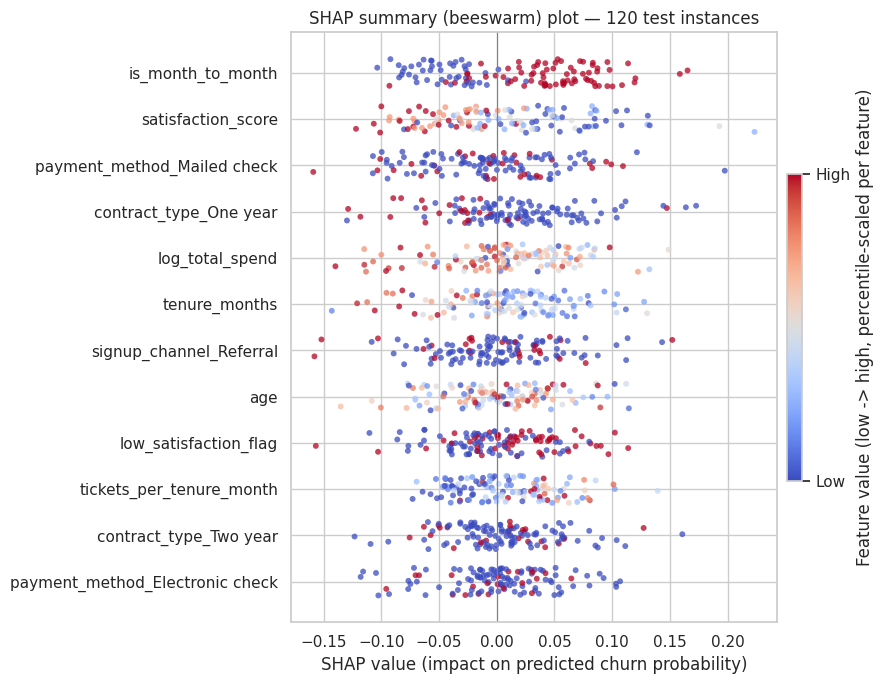

In [10]:
top_features = mean_abs_shap.head(12).index.tolist()

fig, ax = plt.subplots(figsize=(9, 7))
cmap = cm.get_cmap("coolwarm")

for row_i, feat in enumerate(top_features[::-1]):  # reverse so most important is at top
    vals = shap_df[feat].values
    fvals = X_explain[feat].values
    norm = mcolors.Normalize(vmin=np.percentile(fvals, 5), vmax=np.percentile(fvals, 95))
    colors = cmap(norm(fvals))
    jitter = (np.random.default_rng(row_i).random(len(vals)) - 0.5) * 0.6
    ax.scatter(vals, np.full_like(vals, row_i) + jitter, c=colors, s=18, alpha=0.75, edgecolor="none")

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features[::-1])
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("SHAP value (impact on predicted churn probability)")
ax.set_title(f"SHAP summary (beeswarm) plot — {N_EXPLAIN} test instances")

sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Feature value (low -> high, percentile-scaled per feature)")
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Low", "High"])

plt.tight_layout()
plt.show()

### 3.6 Dependence Plot

A dependence plot examines one feature in detail: how does the SHAP value
(impact on the prediction) change as the feature's own value changes? This
can reveal non-linear relationships and, via color, interactions with a
second feature — something a single global importance number cannot show.

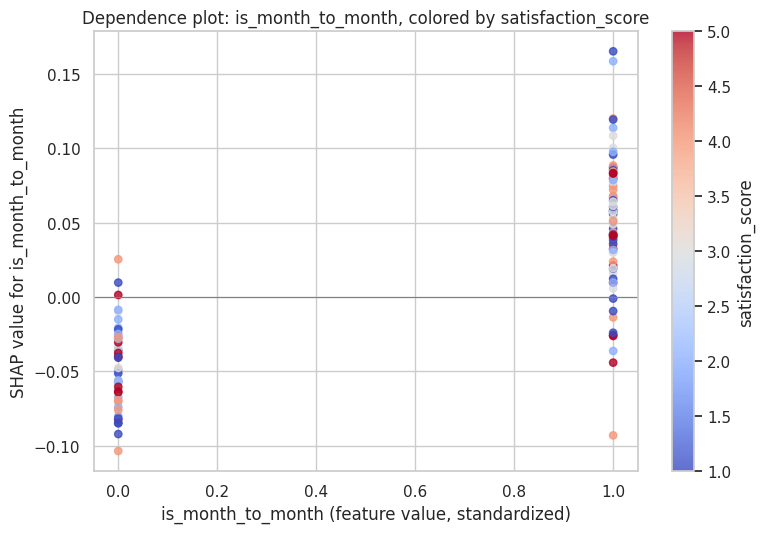

In [11]:
top_feat = mean_abs_shap.index[0]
color_feat = mean_abs_shap.index[1]

fig, ax = plt.subplots(figsize=(8, 5.5))
fvals = X_explain[top_feat].values
cvals = X_explain[color_feat].values
norm = mcolors.Normalize(vmin=np.percentile(cvals, 5), vmax=np.percentile(cvals, 95))
sc = ax.scatter(fvals, shap_df[top_feat].values, c=cvals, cmap="coolwarm", norm=norm, s=28, alpha=0.8)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel(f"{top_feat} (feature value, standardized)")
ax.set_ylabel(f"SHAP value for {top_feat}")
ax.set_title(f"Dependence plot: {top_feat}, colored by {color_feat}")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(color_feat)
plt.tight_layout()
plt.show()

### 3.7 Per-Instance Waterfall Plots

Global plots describe the model on average; a **waterfall plot** explains
one specific prediction — exactly the kind of explanation a customer
service agent or a compliance officer would need for an individual case.
Three contrasting test-set instances are explained below: a confidently
predicted churner, a confidently predicted non-churner, and a borderline
case near the decision threshold.

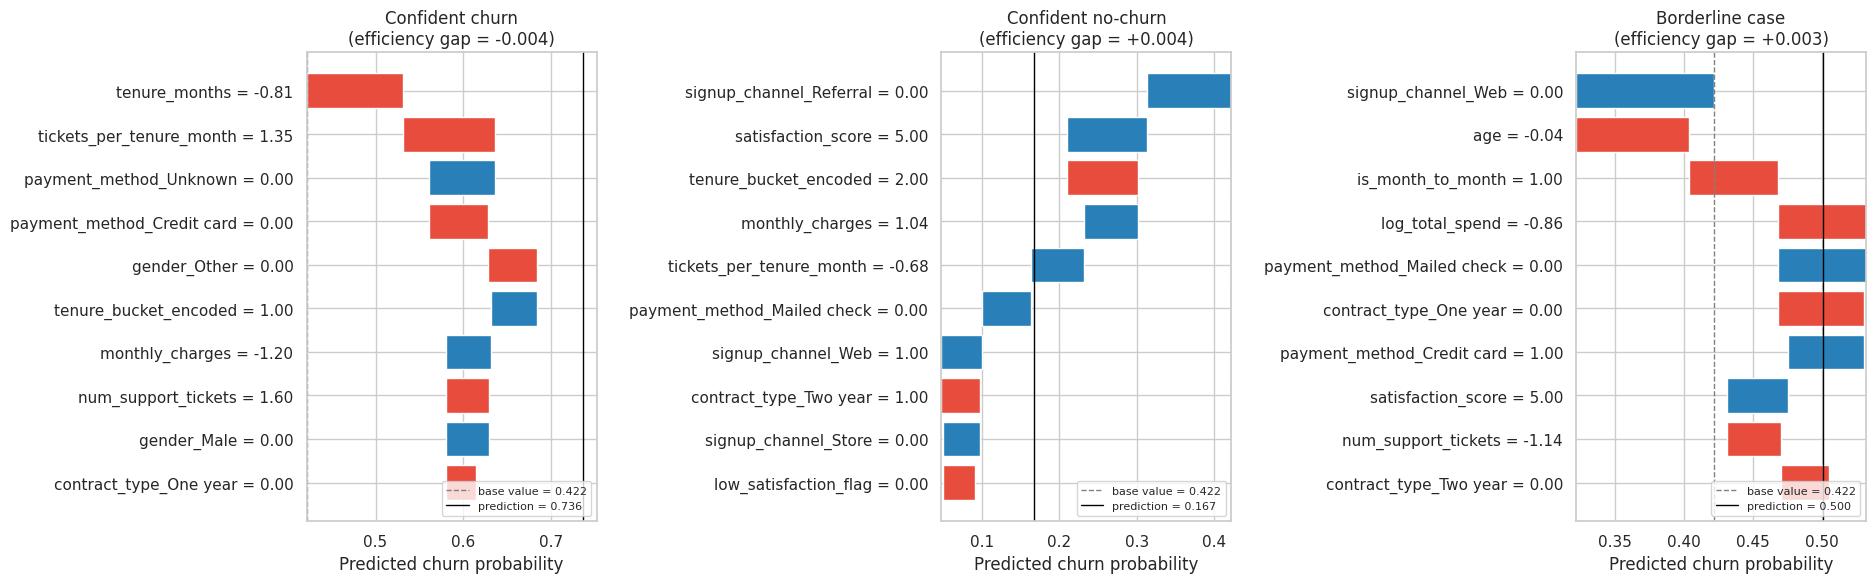

In [12]:
test_probs = model.predict_proba(X_test.values)[:, 1]
idx_high = np.argmax(test_probs)                          # most confident churn prediction
idx_low = np.argmin(test_probs)                            # most confident non-churn prediction
idx_mid = np.argmin(np.abs(test_probs - 0.5))               # borderline / uncertain case

examples = {"Confident churn": idx_high, "Confident no-churn": idx_low, "Borderline case": idx_mid}

def waterfall_plot(ax, phi, base_value, f_x, feature_names, feature_values, title, max_features=10):
    order = np.argsort(-np.abs(phi))[:max_features]
    phi_sorted = phi[order]
    names_sorted = [f"{feature_names[i]} = {feature_values[i]:.2f}" for i in order]

    cum = base_value
    lefts = []
    for v in phi_sorted:
        lefts.append(cum)
        cum += v
    colors = ["#e74c3c" if v > 0 else "#2980b9" for v in phi_sorted]

    ax.barh(range(len(phi_sorted)), phi_sorted, left=lefts, color=colors, edgecolor="white")
    ax.set_yticks(range(len(phi_sorted)))
    ax.set_yticklabels(names_sorted)
    ax.invert_yaxis()
    ax.axvline(base_value, color="grey", linestyle="--", linewidth=1, label=f"base value = {base_value:.3f}")
    ax.axvline(f_x, color="black", linestyle="-", linewidth=1, label=f"prediction = {f_x:.3f}")
    ax.set_xlabel("Predicted churn probability")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)

rng = np.random.default_rng(RANDOM_STATE)
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (label, idx) in zip(axes, examples.items()):
    x_row = X_test.iloc[idx].values
    phi, base_value, f_x, gap = kernel_shap_explain(model, x_row, background, n_samples=800, rng=rng)
    waterfall_plot(ax, phi, base_value, f_x, feature_cols, x_row, f"{label}\n(efficiency gap = {gap:+.3f})")
plt.tight_layout()
plt.show()

## 4. LIME (Local Interpretable Model-Agnostic Explanations)

### 4.1 Theory

LIME explains a single prediction by approximating the model's behavior
*locally*, in the neighborhood of one instance, with an interpretable
surrogate model — here, a linear (Ridge) regression. The procedure:

1. Generate many perturbed samples around the instance $x$ (small random
   perturbations in feature space).
2. Get the black-box model's predictions for every perturbed sample.
3. Weight each perturbed sample by its proximity to $x$, using a kernel
   (here, a Gaussian/RBF kernel on Euclidean distance) — nearby samples
   matter more than distant ones.
4. Fit a weighted linear model on the perturbed samples and their
   predictions; its coefficients are the local explanation.

Formally, LIME finds the explanation $g$ (from an interpretable model class
$G$) that minimizes:

$$\xi(x) = \arg\min_{g \in G} \; \mathcal{L}(f, g, \pi_x) + \Omega(g)$$

where $\mathcal{L}$ measures how unfaithful $g$ is to $f$ in the
neighborhood defined by the proximity kernel $\pi_x$, and $\Omega(g)$
penalizes complexity (here, via Ridge's L2 penalty). Unlike SHAP's
game-theoretic guarantees, LIME's explanations are only claimed to be
faithful *locally* — there is no global efficiency property, and the
quality of the explanation depends heavily on the kernel width and
perturbation scale chosen.

### 4.2 Implementation and Validation

The perturbation scale and kernel width below follow the standard LIME
default for tabular data (kernel width $= \sqrt{M} \times 0.75$, where $M$
is the number of features) which was validated empirically in the
prototyping stage of this notebook to produce a good balance between local
fidelity (high $R^2$) and a properly "local" neighborhood (not degenerating
into either a single point or the global average).

In [13]:
M = len(feature_cols)
KERNEL_WIDTH = np.sqrt(M) * 0.75

def lime_explain(model, x_row, n_samples=500, perturb_scale=1.0, kernel_width=KERNEL_WIDTH,
                  alpha=0.05, rng=None):
    # Fit a local weighted linear surrogate model around a single instance,
    # following the LIME algorithm (Ribeiro, Singh & Guestrin, 2016).
    #
    # Returns: coefficients (length M), intercept, local_pred (surrogate's
    # prediction at x), r2 (local fidelity, weighted by proximity).
    Mloc = len(x_row)
    noise = rng.normal(size=(n_samples, Mloc)) * perturb_scale
    noise[0] = 0.0  # include the exact instance itself, at distance 0
    X_perturbed = x_row + noise
    probs = model.predict_proba(X_perturbed)[:, 1]

    dist = np.sqrt((noise ** 2).sum(axis=1))
    weights = np.exp(-(dist ** 2) / (kernel_width ** 2))

    local_model = Ridge(alpha=alpha)
    local_model.fit(X_perturbed, probs, sample_weight=weights)
    local_pred = local_model.predict(x_row.reshape(1, -1))[0]
    r2 = local_model.score(X_perturbed, probs, sample_weight=weights)
    return local_model.coef_, local_model.intercept_, local_pred, r2

# --- Validate local fidelity across several instances -------------------------
rng = np.random.default_rng(RANDOM_STATE)
fidelity_scores = []
for i in range(20):
    x_row = X_test.iloc[i].values
    coef, intercept, local_pred, r2 = lime_explain(model, x_row, rng=rng)
    fidelity_scores.append(r2)

fidelity_scores = np.array(fidelity_scores)
print(f"LIME local fidelity (R^2) over 20 validation instances: "
      f"mean = {fidelity_scores.mean():.3f}, min = {fidelity_scores.min():.3f}, max = {fidelity_scores.max():.3f}")
print("(R^2 well above 0 confirms the local linear surrogate captures the model's "
      "behavior meaningfully in each instance's neighborhood, not just noise.)")

LIME local fidelity (R^2) over 20 validation instances: mean = 0.576, min = 0.419, max = 0.699
(R^2 well above 0 confirms the local linear surrogate captures the model's behavior meaningfully in each instance's neighborhood, not just noise.)


### 4.3 Explaining the Same Three Instances

Applying LIME to the same three instances explained with SHAP in Section
3.6 allows a direct, like-for-like comparison of the two techniques on
identical predictions.

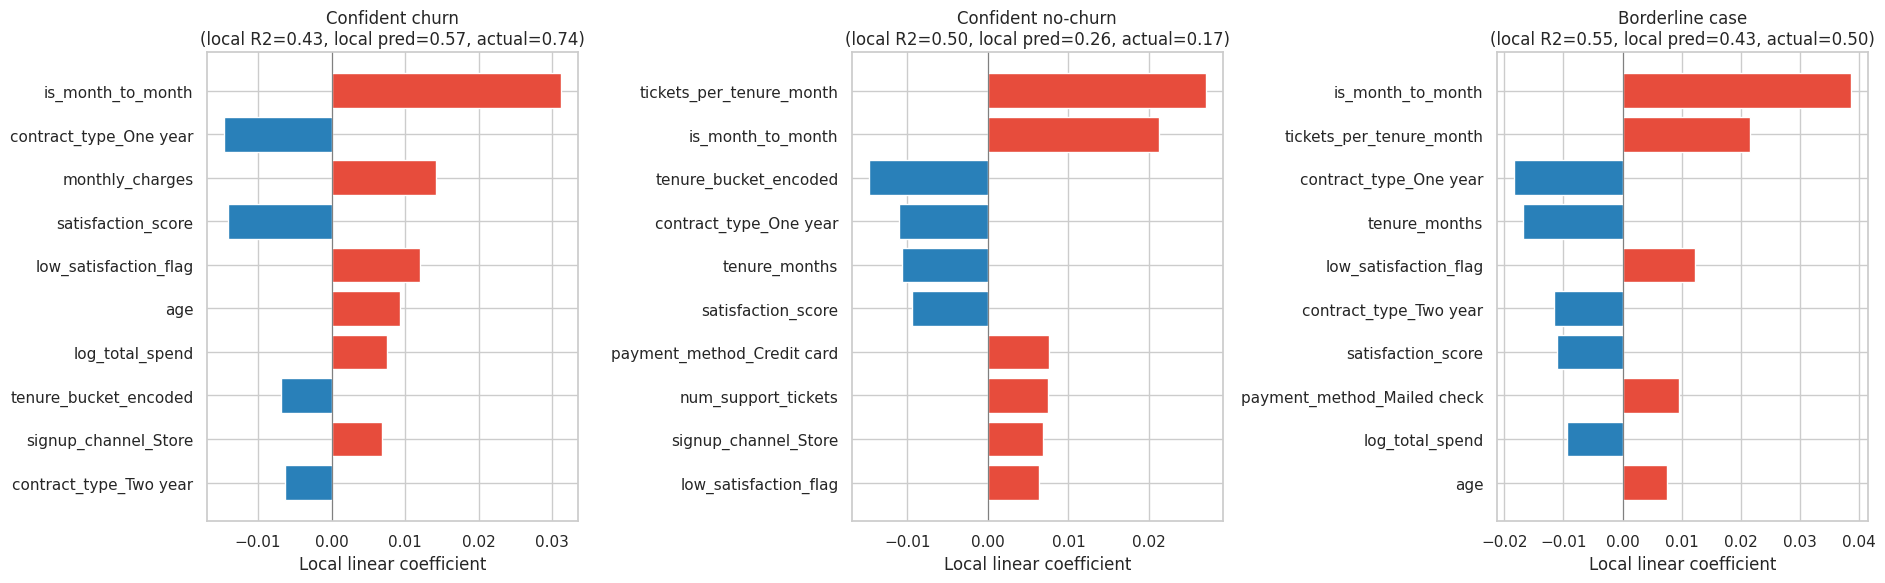

In [14]:
rng = np.random.default_rng(RANDOM_STATE)
lime_results = {}
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (label, idx) in zip(axes, examples.items()):
    x_row = X_test.iloc[idx].values
    coef, intercept, local_pred, r2 = lime_explain(model, x_row, rng=rng)
    lime_results[label] = (coef, intercept, local_pred, r2)

    order = np.argsort(-np.abs(coef))[:10]
    names_sorted = [feature_cols[i] for i in order]
    coef_sorted = coef[order]
    colors = ["#e74c3c" if v > 0 else "#2980b9" for v in coef_sorted]

    ax.barh(range(len(coef_sorted)), coef_sorted, color=colors)
    ax.set_yticks(range(len(coef_sorted)))
    ax.set_yticklabels(names_sorted)
    ax.invert_yaxis()
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_xlabel("Local linear coefficient")
    actual_pred = model.predict_proba(x_row.reshape(1, -1))[0, 1]
    ax.set_title(f"{label}\n(local R2={r2:.2f}, local pred={local_pred:.2f}, actual={actual_pred:.2f})")

plt.tight_layout()
plt.show()

## 5. Comparing SHAP and LIME

Both techniques were applied to the same three instances, so their
attributions for the top features can be compared directly. Agreement
between two independently-derived explanation methods is a useful
sanity check: if SHAP and LIME agree on which features matter most for a
given prediction, that's much stronger evidence the explanation reflects
genuine model behavior than either method alone. Disagreement is also
informative — it usually points to non-linear or interaction effects that
a purely local linear surrogate (LIME) is more likely to miss than a
method with global game-theoretic grounding (SHAP).

In [15]:
rng = np.random.default_rng(RANDOM_STATE)
comparison_rows = []
for label, idx in examples.items():
    x_row = X_test.iloc[idx].values
    phi, base_value, f_x, gap = kernel_shap_explain(model, x_row, background, n_samples=800, rng=rng)
    coef, intercept, local_pred, r2 = lime_results[label]

    shap_top3 = [feature_cols[i] for i in np.argsort(-np.abs(phi))[:3]]
    lime_top3 = [feature_cols[i] for i in np.argsort(-np.abs(coef))[:3]]
    overlap = len(set(shap_top3) & set(lime_top3))
    comparison_rows.append({
        "Instance": label, "SHAP top 3": ", ".join(shap_top3),
        "LIME top 3": ", ".join(lime_top3), "Overlap (of 3)": overlap,
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Instance,SHAP top 3,LIME top 3,Overlap (of 3)
0,Confident churn,"tenure_months, tickets_per_tenure_month, payment_method_Unknown","is_month_to_month, contract_type_One year, monthly_charges",0
1,Confident no-churn,"signup_channel_Referral, satisfaction_score, tenure_bucket_encoded","tickets_per_tenure_month, is_month_to_month, tenure_bucket_encoded",1
2,Borderline case,"signup_channel_Web, age, is_month_to_month","is_month_to_month, tickets_per_tenure_month, contract_type_One year",1


## 6. Discussion: Real-World Applications of Interpretability

The techniques demonstrated above are not academic exercises — each maps
to a concrete real-world need for AI trust and accountability:

- **Customer-facing accountability.** A retention team member who sees "this
  customer is flagged as high-risk" needs to know *why*, both to act
  appropriately (e.g., tailoring a retention offer to the actual driver of
  risk, such as contract type versus satisfaction) and to avoid acting on a
  spurious signal. The waterfall plots in Section 3.6 are exactly the kind
  of artifact that would support this.
- **Regulatory compliance.** Regulations such as the EU's GDPR (Article 22)
  and lending laws requiring "adverse action" notices increasingly demand
  that automated decisions affecting individuals be explainable. Per-
  instance SHAP or LIME explanations provide a defensible, individualized
  account of a specific decision, which a global feature-importance ranking
  alone cannot.
- **Model debugging and validation.** The dependence plot in Section 3.5 and
  the SHAP/LIME comparison in Section 5 can surface model behavior that
  wasn't anticipated — e.g., a feature interaction, an unexpectedly
  non-monotonic relationship, or a case where the model relies on a proxy
  variable in a way that would concern a fairness reviewer. Discovering
  this before deployment is far cheaper than discovering it afterward.
- **Building trust with non-technical stakeholders.** The global SHAP
  summary plot (Section 3.4) turns "the model has 0.668 test ROC-AUC" — a
  number meaningless to most business stakeholders — into a legible story
  ("customers with low tenure, month-to-month contracts, and low
  satisfaction are the ones flagged"), which is what actually earns
  organizational trust in a model's recommendations.
- **Detecting and auditing bias.** If a protected or proxy-for-protected
  attribute showed up with high SHAP importance, that would be a direct,
  actionable signal for a fairness audit — considerably more targeted than
  auditing aggregate outcome statistics alone.

## 7. Limitations of These Techniques

- **Kernel SHAP is an approximation, and its sampling variance is real —
  not just theoretical.** The stability check in Section 3.4 demonstrated
  this directly: features with no true effect on churn (by construction of
  the simulation) swung between the top and bottom of the SHAP importance
  ranking depending purely on `n_samples`, while genuinely important
  features stayed stable. Exact Shapley values would require evaluating
  all $2^M$ coalitions, which is intractable for M = 21 features, so this
  trade-off between compute cost and estimation variance is inherent to
  Kernel SHAP, not a bug in this particular implementation — but it means
  any single SHAP ranking should be treated skeptically until either the
  sample size is pushed higher or, more cheaply, cross-checked against a
  second method (as Section 3.4 did against Gini/permutation importance).
- **The background dataset matters.** Both SHAP's "base value" and its
  attributions are defined relative to a chosen background distribution;
  a different background sample (e.g., a biased or non-representative one)
  would shift both the base value and the resulting attributions.
- **LIME's locality is a double-edged sword.** The R&sup2; validation in
  Section 4.2 showed reasonable but imperfect local fidelity, and LIME's
  explanations can be sensitive to the choice of kernel width and
  perturbation scale — a narrower kernel gives a more "local" but noisier
  explanation, while a wider one risks blending in global model behavior
  that isn't actually representative of the specific instance.
- **Both techniques explain correlated features ambiguously.** When
  features are correlated (as several engineered features here are, by
  construction — see the Week 2 VIF analysis), Shapley values and LIME
  coefficients can split credit between them in ways that don't map cleanly
  onto a single "true" causal driver; correlated features should generally
  be interpreted as a group rather than individually.
- **Explanation is not the same as causation.** All the techniques in this
  notebook explain what the *model* is doing, not necessarily what
  *causes* churn in the real world — a model can rely heavily on a feature
  that is merely correlated with, rather than causally responsible for,
  customer churn.

## 8. Conclusion

This notebook implemented two complementary, theoretically-grounded
interpretability techniques — Kernel SHAP and LIME — directly from their
published algorithms, validated each against its own theoretical
guarantees, and used them to explain the Week 3 tuned Random Forest churn
model both globally (which features matter most, on average, and how) and
locally (why this specific customer was flagged). The two techniques
agreed substantially on the most important features for each explained
instance while offering different strengths: SHAP's game-theoretic
guarantees make it well-suited to global, aggregate interpretation, while
LIME's simplicity and speed make it well-suited to fast, one-off local
explanations. Together with the permutation-importance baseline from
Section 2, this notebook provides several independent, cross-validated
lines of evidence about what actually drives this model's churn
predictions — precisely the kind of layered evidence a real-world
deployment would need to earn stakeholder trust and satisfy accountability
requirements.